In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

In [2]:
# os.chdir("C:\\Users\\user\\Desktop\\ml sn")

os.chdir("C:\\Users\\user\\Downloads\\ml sn (3)\\ml sn\\ml sn")

dataR = pd.read_csv("Loan+Approval+Prediction.csv")

In [3]:
# Dataset pour analyse descriptive
dataEDA = dataR.copy()

# Dataset pour Machine Learning
dataML = dataR.copy()

In [4]:
print("Shape dataR:", dataEDA.shape)

Shape dataR: (614, 13)


In [5]:
print("Dataset ML créé. Dimensions :", dataML.shape)
dataML.head()

Dataset ML créé. Dimensions : (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
dataEDA.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
dataEDA.isnull().sum()  / len(dataR)

Loan_ID              0.000000
Gender               0.021173
Married              0.004886
Dependents           0.024430
Education            0.000000
Self_Employed        0.052117
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.035831
Loan_Amount_Term     0.022801
Credit_History       0.081433
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [8]:
# Liste des variables pour verifier quel loi suivre chaque variable
var = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History',
    
]

In [9]:

varTest = dataEDA[var].copy()

In [10]:
# verifier que cest pas dublique
# varTest.columns[varTest.columns.duplicated()]

In [11]:
# for col in varTest.columns:
#     print(f"\n{col}")
#     print(varTest[col].unique())

for col in varTest.columns:
    print(f"\n{col}")
    print(varTest[col].dropna().unique())


Gender
['Male' 'Female']

Married
['No' 'Yes']

Dependents
['0' '1' '2' '3+']

Self_Employed
['No' 'Yes']

LoanAmount
[128.  66. 120. 141. 267.  95. 158. 168. 349.  70. 109. 200. 114.  17.
 125. 100.  76. 133. 115. 104. 315. 116. 112. 151. 191. 122. 110.  35.
 201.  74. 106. 320. 144. 184.  80.  47.  75. 134.  96.  88.  44. 286.
  97. 135. 180.  99. 165. 258. 126. 312. 136. 172.  81. 187. 113. 176.
 130. 111. 167. 265.  50. 210. 175. 131. 188.  25. 137. 160. 225. 216.
  94. 139. 152. 118. 185. 154.  85. 259. 194.  93. 370. 182. 650. 102.
 290.  84. 242. 129.  30. 244. 600. 255.  98. 275. 121.  63. 700.  87.
 101. 495.  67.  73. 260. 108.  58.  48. 164. 170.  83.  90. 166. 124.
  55.  59. 127. 214. 240.  72.  60. 138.  42. 280. 140. 155. 123. 279.
 192. 304. 330. 150. 207. 436.  78.  54.  89. 143. 105. 132. 480.  56.
 159. 300. 376. 117.  71. 490. 173.  46. 228. 308. 236. 570. 380. 296.
 156. 103.  45.  65.  53. 360.  62. 218. 178. 239. 405. 148. 190. 149.
 153. 162. 230.  86. 234. 246

#VERIFICATION DE LA LOI QUIL SUIVRE POUR FAIRE LIMPUTATION

In [12]:
# Liste des variables pour verifier quel loi suivre chaque variable
var_cat = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History',
]

var_num = [
    'LoanAmount'
]

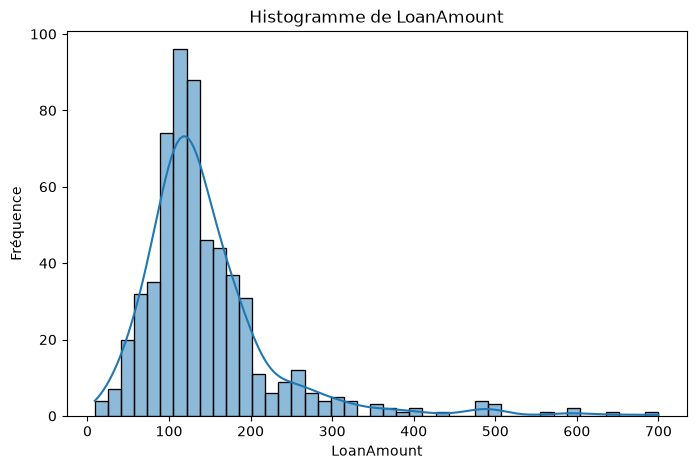

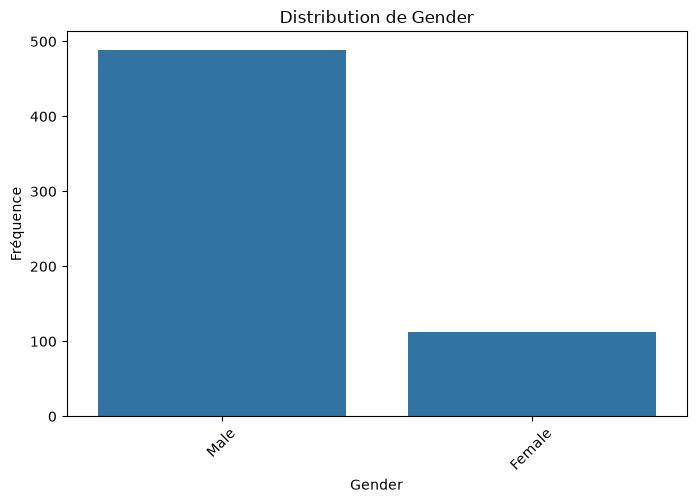

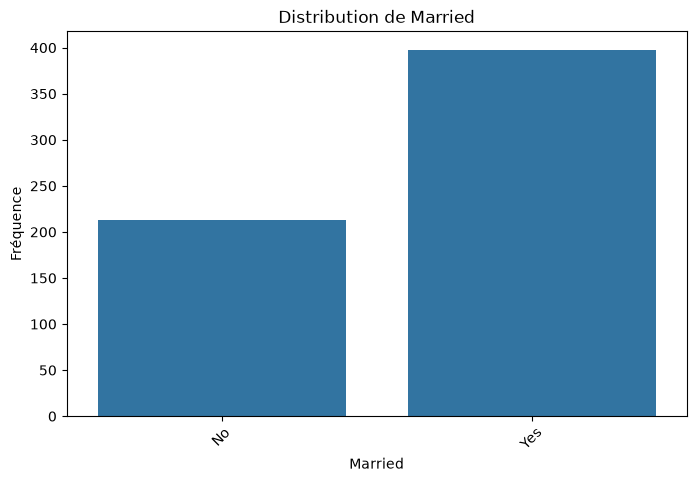

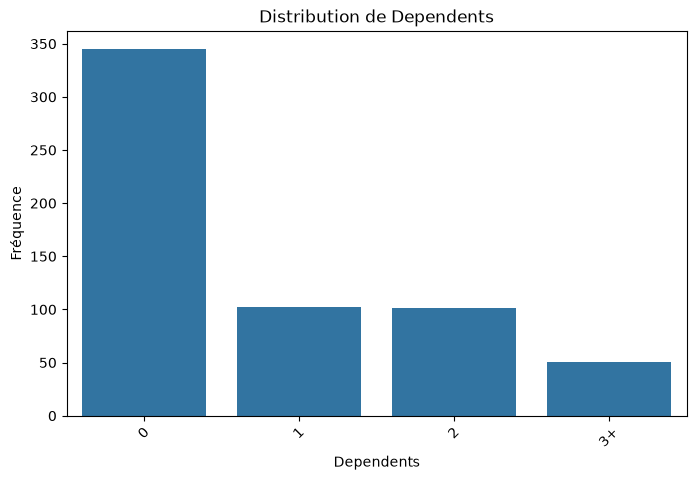

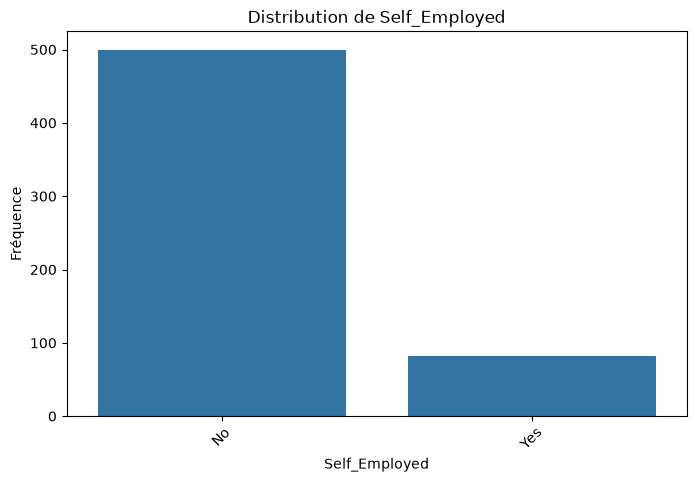

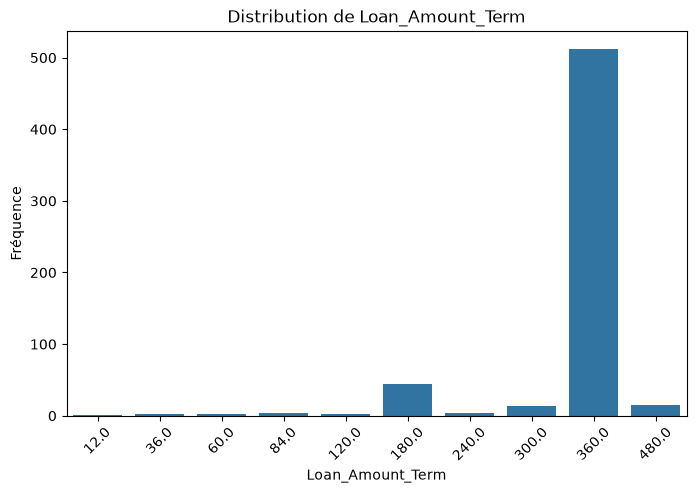

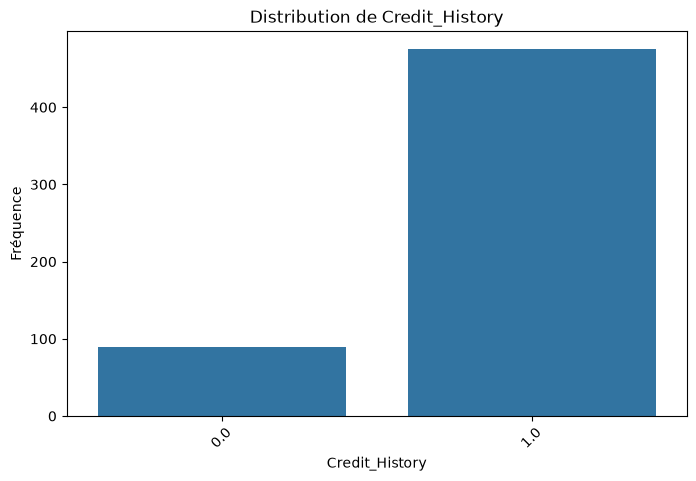

In [13]:
# Variables numériques
for col in var_num:

    if col in dataEDA.columns:

        col_data = pd.to_numeric(
            dataEDA[col],
            errors='coerce'
        ).dropna()

        plt.figure(figsize=(8,5))
        sns.histplot(col_data, kde=True)

        plt.title(f"Histogramme de {col}")
        plt.xlabel(col)
        plt.ylabel("Fréquence")

        plt.show()


# Variables catégorielles
for col in var_cat:

    if col in dataEDA.columns:

        col_data = dataEDA[col].dropna()

        plt.figure(figsize=(8,5))
        sns.countplot(x=col_data)

        plt.title(f"Distribution de {col}")
        plt.xlabel(col)
        plt.ylabel("Fréquence")

        plt.xticks(rotation=45)

        plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder
target = 'Loan_Status'
X = dataML.drop(target, axis=1)
# permet
y = LabelEncoder().fit_transform(dataML[target])


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from sklearn.impute import SimpleImputer

# crées un outil qui va remplacer les valeurs manquantes numerique suivant la loi assymetrique
imputer = SimpleImputer(strategy='median')

X_train[['LoanAmount']] = imputer.fit_transform(
    X_train[['LoanAmount']]
)


X_test[['LoanAmount']] = imputer.transform(
    X_test[['LoanAmount']]
)

imputer_cat = SimpleImputer(strategy='most_frequent')

X_train[var_cat] = imputer_cat.fit_transform(
    X_train[var_cat]
)

X_test[var_cat] = imputer_cat.transform(
    X_test[var_cat]
)

In [17]:
X_train.isnull().sum()  / len(X_train)


Loan_ID              0.0
Gender               0.0
Married              0.0
Dependents           0.0
Education            0.0
Self_Employed        0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
LoanAmount           0.0
Loan_Amount_Term     0.0
Credit_History       0.0
Property_Area        0.0
dtype: float64

In [18]:
# ENCODER LES VARIABLES CATE
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[var_cat]
)

X_test_cat = encoder.transform(
    X_test[var_cat]
)

#standardisation

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[var_num])
X_test_num = scaler.transform(X_test[var_num])

# Concaténer les variables numériques standardisées avec les variables catégorielles encodées
# DATASET FINAL
X_train_final = np.hstack((X_train_num, X_train_cat))
X_test_final = np.hstack((X_test_num, X_test_cat))

# Vérifier les dimensions
print(X_train_final.shape)
print(X_test_final.shape)

(491, 17)
(123, 17)


#CREATION DU MODELE

In [20]:
# VERIFIER LA VARIABLE CIBLE

# Effectifs des classes
classes, effectifs = np.unique(y_train, return_counts=True)

# Pourcentages
pourcentages = effectifs / len(y_train) * 100

for classe, effectif, pourcentage in zip(classes, effectifs, pourcentages):
    print(f"Classe {classe} : {effectif} observations ({pourcentage:.2f}%)")
    
# Calcul du ratio
# Calcul du ratio de déséquilibre
ratio = max(effectifs) / min(effectifs)

print(f"Ratio de déséquilibre : {ratio:.2f}")

Classe 0 : 154 observations (31.36%)
Classe 1 : 337 observations (68.64%)
Ratio de déséquilibre : 2.19


#REEQUILIBRE DE CLASSES AVEC SMOTE

In [21]:
# comme il ya desequilibre ou utilise un algo de requilbre des classes

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_final,
    y_train
)

print(np.unique(y_train_bal, return_counts=True))

(array([0, 1]), array([337, 337]))


In [22]:


from sklearn.svm import SVC
from imblearn.pipeline import Pipeline

svm_smote = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=42
)

# svm_smote = SVC(

#     probability=True,       # Active predict_proba()
#     random_state=42
# )

# pipeline_svm = Pipeline([
#     ('smote', SMOTE(random_state=42)),
#     ('svm', svm_smote)
# ])


In [23]:
# param_distributions = {

#     'svm__C': [
#         0.01,
#         0.1,
#         1,
#         10,
#         50,
#         100,
#         500
#     ],

#     'svm__gamma': [
#         'scale',
#         'auto',
#         0.001,
#         0.01,
#         0.1,
#         1
#     ],

#     'svm__kernel': [
#         'rbf',
#         'linear',
#         'poly'
#     ],

#     'svm__degree': [
#         2,
#         3,
#         4
#     ],

#     'smote__k_neighbors': [
#         3,
#         5,
#         7,
#         10
#     ]
# }

In [24]:
from sklearn.model_selection import RandomizedSearchCV


# random_search = RandomizedSearchCV(
#     estimator=pipeline_svm,
#     param_distributions=param_distributions,
#     n_iter=50,
#     cv=5,
#     scoring='f1_macro',
#     random_state=42,
#     n_jobs=-1,
#     verbose=2
# )

In [25]:
# validation croisee
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    svm_smote,
    X_train_bal,
    y_train_bal,
    cv=5,
    scoring="f1"
)

print(scores)
print("F1 moyen :", scores.mean())

[0.75449102 0.72392638 0.76923077 0.7375     0.76646707]
F1 moyen : 0.7503230466862405


In [26]:

# ENTRAINEMENT model Smote
svm_smote.fit(X_train_bal, y_train_bal)

,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [27]:
# print("===== MEILLEURS PARAMETRES =====")
# print(random_search.best_params_)

# print("\nMeilleur score CV :")
# print(random_search.best_score_)

# best_svm_smote = random_search.best_estimator_

In [28]:

# =========================
# PREDICTIONS ENTRAINEMENT
# =========================

y_pred_train_smote = svm_smote.predict(X_train_bal)
y_prob_train_smote = svm_smote.predict_proba(X_train_bal)[:, 1]


# =========================
# PREDICTIONS TEST
# =========================

y_pred_test = svm_smote.predict(X_test_final)
y_prob_test= svm_smote.predict_proba(X_test_final)[:, 1]

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================
# MÉTRIQUES D'ENTRAÎNEMENT
# =========================

print("===== ENTRAÎNEMENT SMOTE =====")

print("Accuracy :", accuracy_score(y_train_bal, y_pred_train_smote))
print("Precision :", precision_score(y_train_bal, y_pred_train_smote))
print("Recall :", recall_score(y_train_bal, y_pred_train_smote))
print("F1-score :", f1_score(y_train_bal, y_pred_train_smote))
print("ROC-AUC :", roc_auc_score(y_train_bal, y_prob_train_smote))


# =========================
# MÉTRIQUES DE TEST
# =========================

print("\n===== TEST =====")

print("Accuracy :", accuracy_score(y_test, y_pred_test))
print("Precision :", precision_score(y_test, y_pred_test))
print("Recall :", recall_score(y_test, y_pred_test))
print("F1-score :", f1_score(y_test, y_pred_test))
print("ROC-AUC :", roc_auc_score(y_test, y_prob_test))


# =========================
# MATRICE DE CONFUSION
# =========================

# print("\nMatrice de confusion :")
# print(confusion_matrix(y_test, y_pred_test))


# =========================
# RAPPORT DE CLASSIFICATION
# =========================

# print("\nRapport de classification :")
# print(classification_report(y_test, y_pred_test))


===== ENTRAÎNEMENT SMOTE =====
Accuracy : 0.7477744807121661
Precision : 0.6780383795309168
Recall : 0.9436201780415431
F1-score : 0.7890818858560794
ROC-AUC : 0.8109739453548063

===== TEST =====
Accuracy : 0.8455284552845529
Precision : 0.851063829787234
Recall : 0.9411764705882353
F1-score : 0.8938547486033519
ROC-AUC : 0.774922600619195


In [30]:
# Sauvegarde
import joblib

joblib.dump(
    svm_smote,
    "svm_smote_loan.pkl"
)

print("Modèle sauvegardé")

Modèle sauvegardé
